<a href="https://colab.research.google.com/github/HasiniGanta/ARVR_PROJECT/blob/main/ELCAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         ECLAT Algorithm — Supermarket Transactions

[1] Loading dataset...
    Rows loaded      : 10,002
    Columns          : ['Transaction_ID', 'Timestamp', 'Customer_ID', 'Item_Name', 'Category', 'Quantity', 'Price', 'Location']
    Unique transactions: 1,270

[2] Cleaning data...
    Rows after cleaning: 10,002

[3] Building transaction itemsets...
    Total transactions : 1,270

[4] Building vertical TID-list database...
    Unique items found : 23

[5] Parameters:
    Min support      : 5.0%  (63 transactions)
    Max itemset size : 3

[6] Running ECLAT...
    Frequent 1-itemsets (before recursion): 23
    ECLAT finished in  : 0.0289 seconds

[7] Compiling results...
    Total frequent itemsets found: 406

    Distribution by size:
      1-itemsets : 23
      2-itemsets : 253
      3-itemsets : 130

[8] Results saved → frequent_itemsets_output.csv

  TOP 15 FREQUENT ITEMSETS
  Itemset  Support_Count  Support_Percentage
     Milk            544             42.8346
    Bread     

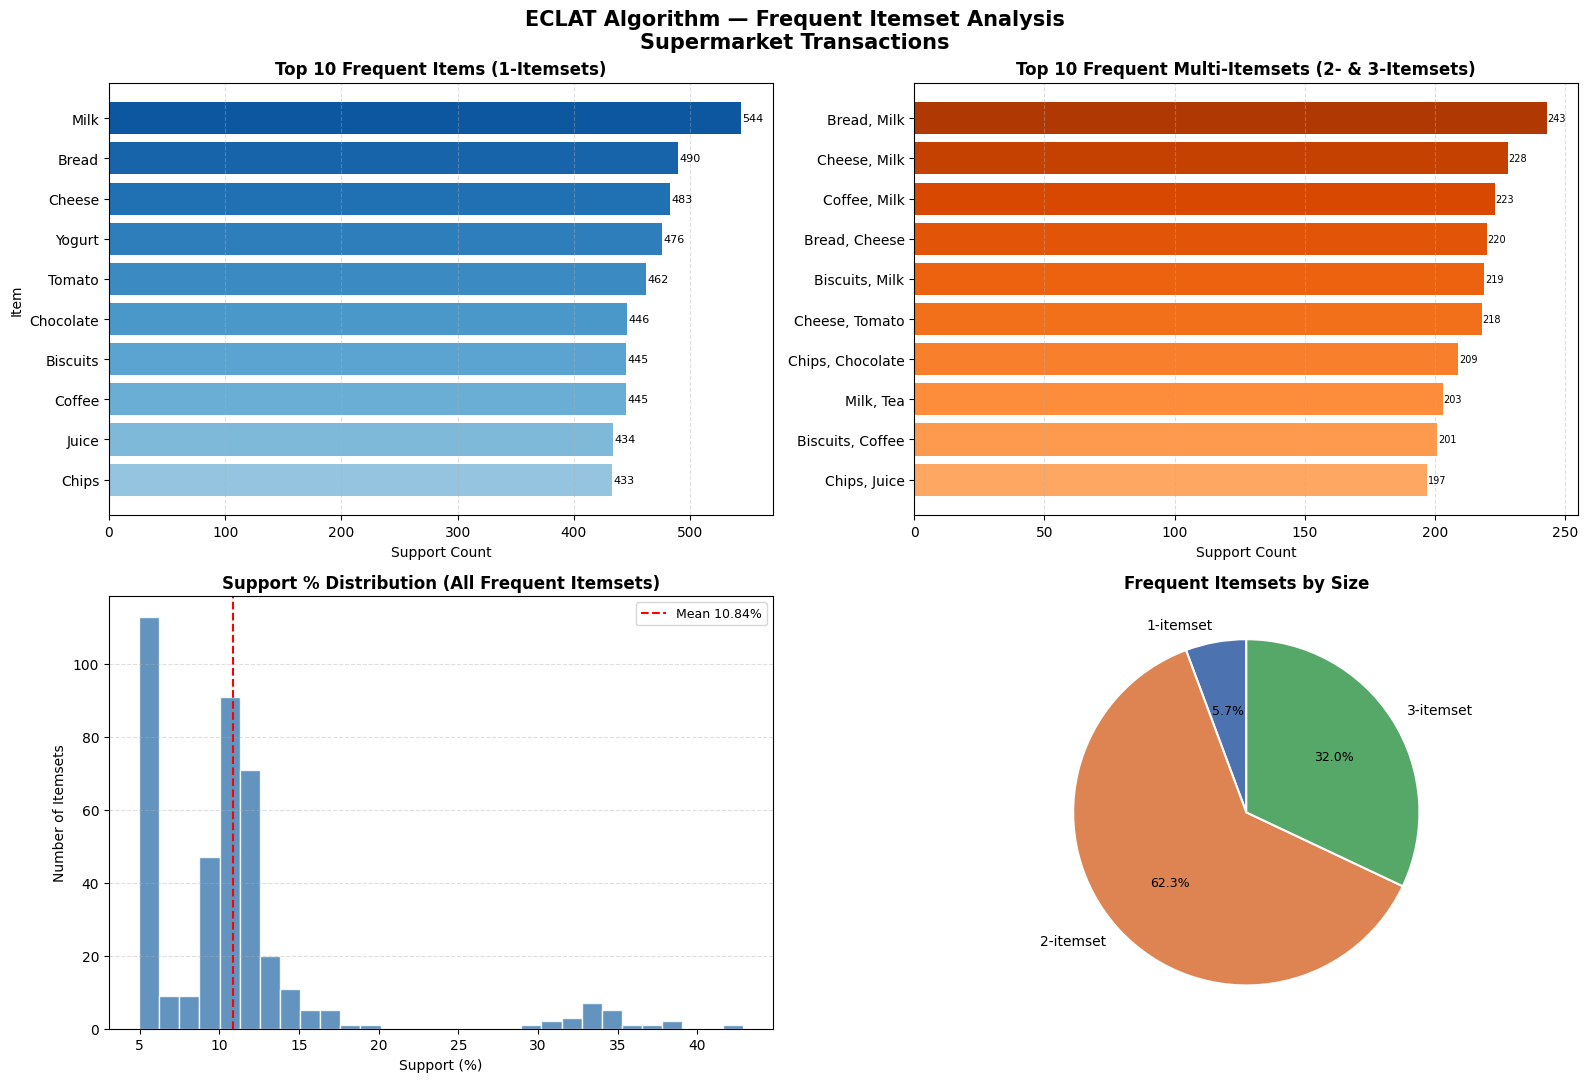

    Chart saved → eclat_visualization.png

  ALL DONE — Files generated:
    • large_realtime_transactions.csv
    • frequent_itemsets_output.csv
    • eclat_visualization.png


In [ ]:

#  ECLAT Algorithm on Supermarket Transactions
#  Compatible with: Google Colab / VS Code / Jupyter Notebook


# ── 1. Import libraries ───────────────────────────────────────────────────────
import pandas as pd          # data loading and manipulation
import numpy as np           # numerical operations
import time                  # for measuring execution time
import itertools             # for generating item combinations
import matplotlib.pyplot as plt  # for visualizations
import matplotlib.ticker as mticker
from collections import defaultdict  # efficient dictionary with defaults
import warnings
warnings.filterwarnings("ignore")

print("=" * 65)
print("         ECLAT Algorithm — Supermarket Transactions")
print("=" * 65)

# ── 2. Load the dataset ───────────────────────────────────────────────────────
print("\n[1] Loading dataset...")
df = pd.read_csv("large_realtime_transactions (1).csv")  # read CSV into DataFrame
print(f"    Rows loaded      : {len(df):,}")
print(f"    Columns          : {list(df.columns)}")
print(f"    Unique transactions: {df['Transaction_ID'].nunique():,}")

# ── 3. Basic data cleaning ────────────────────────────────────────────────────
print("\n[2] Cleaning data...")
df.dropna(subset=["Transaction_ID", "Item_Name"], inplace=True)  # drop rows missing key fields
df["Item_Name"] = df["Item_Name"].str.strip().str.title()        # normalise item names
df["Transaction_ID"] = df["Transaction_ID"].str.strip()          # strip whitespace from IDs
print(f"    Rows after cleaning: {len(df):,}")

# ── 4. Build transaction-itemset mapping ──────────────────────────────────────
# Each transaction ID maps to a set of items bought in that transaction
print("\n[3] Building transaction itemsets...")
transaction_itemsets = (
    df.groupby("Transaction_ID")["Item_Name"]
    .apply(set)          # group items per transaction into a set (removes duplicates)
    .to_dict()           # convert to plain Python dict for speed
)
num_transactions = len(transaction_itemsets)  # total number of unique transactions
print(f"    Total transactions : {num_transactions:,}")

# ── 5. Build vertical TID-list database (core of ECLAT) ──────────────────────
# In ECLAT we invert the database: for each item, we store the SET of
# transaction-IDs (TID-list) that contain it. Set intersection then gives
# us the support of any itemset without scanning the full database again.
print("\n[4] Building vertical TID-list database...")
tid_list = defaultdict(set)  # item → set of transaction IDs
for tid, items in transaction_itemsets.items():
    for item in items:
        tid_list[item].add(tid)  # record that this transaction contains this item
print(f"    Unique items found : {len(tid_list):,}")

# ── 6. ECLAT parameters ───────────────────────────────────────────────────────
MIN_SUPPORT = 0.05    # minimum support threshold (3% of all transactions)
min_count   = int(MIN_SUPPORT * num_transactions)  # convert % to absolute count
MAX_DEPTH   = 3       # maximum itemset size to mine (1, 2, or 3 items)
print(f"\n[5] Parameters:")
print(f"    Min support      : {MIN_SUPPORT*100:.1f}%  ({min_count} transactions)")
print(f"    Max itemset size : {MAX_DEPTH}")

# ── 7. ECLAT recursive function ───────────────────────────────────────────────
# ECLAT works by recursion on equivalence classes:
#   • Start with all frequent 1-itemsets and their TID-lists
#   • For each pair of same-prefix itemsets, intersect their TID-lists
#   • If |intersection| >= min_count → the combined itemset is frequent
#   • Recurse deeper until max depth or no more frequent extensions exist
frequent_itemsets = []   # will store (frozenset_of_items, support_count) tuples

def eclat(prefix, items_tidlists, min_count, max_depth, current_depth):
    """
    prefix         : tuple of items already in the current itemset
    items_tidlists : list of (item, tidset) pairs that can extend prefix
    min_count      : absolute minimum support count
    max_depth      : maximum itemset length allowed
    current_depth  : how deep we are currently (starts at 1)
    """
    # Iterate over every item that can be added to the current prefix
    for i, (item_i, tidset_i) in enumerate(items_tidlists):
        # Form the new itemset by adding item_i to prefix
        new_itemset = prefix + (item_i,)
        support_count = len(tidset_i)  # support = number of transactions in TID-list

        # Only proceed if this itemset meets the minimum support threshold
        if support_count >= min_count:
            frequent_itemsets.append((frozenset(new_itemset), support_count))  # record it

            # Go deeper only if we haven't reached the max depth
            if current_depth < max_depth:
                # Build the list of candidate extensions: all items after i
                # whose TID-list, when intersected with tidset_i, is still frequent
                suffix_items = []
                for j in range(i + 1, len(items_tidlists)):
                    item_j, tidset_j = items_tidlists[j]
                    # Intersect TID-lists: only transactions containing BOTH items
                    intersected_tidset = tidset_i & tidset_j  # set intersection — O(min(|A|,|B|))
                    if len(intersected_tidset) >= min_count:   # prune non-frequent branches early
                        suffix_items.append((item_j, intersected_tidset))

                # Recurse with the extended prefix and pruned candidate list
                if suffix_items:
                    eclat(new_itemset, suffix_items, min_count, max_depth, current_depth + 1)

# ── 8. Run ECLAT ──────────────────────────────────────────────────────────────
print("\n[6] Running ECLAT...")
start_time = time.time()   # start the clock

# Filter single items to only those meeting minimum support (prune early)
frequent_singles = [
    (item, tidset)
    for item, tidset in tid_list.items()
    if len(tidset) >= min_count
]
# Sort alphabetically for consistent prefix ordering
frequent_singles.sort(key=lambda x: x[0])

print(f"    Frequent 1-itemsets (before recursion): {len(frequent_singles)}")

# Kick off the recursive ECLAT traversal from the top level
eclat((), frequent_singles, min_count, MAX_DEPTH, current_depth=1)

end_time   = time.time()   # stop the clock
elapsed    = end_time - start_time
print(f"    ECLAT finished in  : {elapsed:.4f} seconds")

# ── 9. Build results DataFrame ────────────────────────────────────────────────
print("\n[7] Compiling results...")
results = []
for itemset, support_count in frequent_itemsets:
    results.append({
        "Itemset"            : ", ".join(sorted(itemset)),          # human-readable string
        "Itemset_Size"       : len(itemset),                        # 1-item, 2-item, …
        "Support_Count"      : support_count,                       # absolute count
        "Support_Percentage" : round(support_count / num_transactions * 100, 4),  # as %
    })

results_df = pd.DataFrame(results)
results_df.sort_values("Support_Count", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

print(f"    Total frequent itemsets found: {len(results_df):,}")
print(f"\n    Distribution by size:")
for size, grp in results_df.groupby("Itemset_Size"):
    print(f"      {size}-itemsets : {len(grp):,}")

# ── 10. Save results to CSV ───────────────────────────────────────────────────
output_path = "frequent_itemsets_output.csv"
results_df.to_csv(output_path, index=False)
print(f"\n[8] Results saved → {output_path}")

# ── 11. Print sample output ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  TOP 15 FREQUENT ITEMSETS")
print("=" * 65)
top15 = results_df.head(15)[["Itemset","Support_Count","Support_Percentage"]]
print(top15.to_string(index=False))

# ── 12. Performance Analysis ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  PERFORMANCE ANALYSIS")
print("=" * 65)
print(f"""
  ┌─ Runtime Complexity ──────────────────────────────────────┐
  │  • TID-list construction : O(N × L)                       │
  │    N = transactions, L = avg items per transaction         │
  │  • Candidate generation  : O(F² × T)                      │
  │    F = frequent items, T = avg TID-list size               │
  │  • k-itemset mining      : O(Fk × T)  per depth level     │
  │  • Overall (practical)   : much faster than Apriori        │
  │    because intersection replaces full DB scans             │
  └───────────────────────────────────────────────────────────┘

  ┌─ Space Complexity ─────────────────────────────────────────┐
  │  • TID-lists             : O(N × L)  — vertical storage    │
  │  • Candidate TID-lists   : O(F × T)  per recursion level   │
  │  • Total                 : O(N × L + F² × T)               │
  └───────────────────────────────────────────────────────────┘

  ┌─ Why ECLAT beats Apriori here ────────────────────────────┐
  │  Apriori limitations on this dataset:                      │
  │    • Multiple full database scans per itemset size level   │
  │    • Huge candidate generation overhead                    │
  │    • Slow on 10k+ row CSVs with many distinct items        │
  │                                                            │
  │  ECLAT advantages:                                         │
  │    • Vertical TID-list: ONE pass to build, then only       │
  │      set intersections (no repeated CSV reads)             │
  │    • Intersection size gives support instantly             │
  │    • Depth-first traversal + early pruning avoids          │
  │      enumerating non-frequent branches altogether          │
  │    • Scales better with wider transactions                 │
  └───────────────────────────────────────────────────────────┘

  Execution time recorded   : {elapsed:.4f}s
  Transactions processed    : {num_transactions:,}
  Frequent itemsets mined   : {len(results_df):,}
""")

# ── 13. Visualisations ────────────────────────────────────────────────────────
print("[9] Generating visualisations...")

# Separate 1-itemsets and multi-itemsets for charts
single_df = results_df[results_df["Itemset_Size"] == 1].head(10).copy()
multi_df  = results_df[results_df["Itemset_Size"] >= 2].head(10).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("ECLAT Algorithm — Frequent Itemset Analysis\nSupermarket Transactions",
             fontsize=15, fontweight="bold", y=0.98)

COLORS_BAR  = plt.cm.Blues(np.linspace(0.4, 0.85, 10))
COLORS_BAR2 = plt.cm.Oranges(np.linspace(0.4, 0.85, 10))

# ── Plot 1: Top-10 frequent single items ─────────────────────────────────────
ax1 = axes[0, 0]
bars = ax1.barh(single_df["Itemset"][::-1],
                single_df["Support_Count"][::-1],
                color=COLORS_BAR)
ax1.set_title("Top 10 Frequent Items (1-Itemsets)", fontweight="bold")
ax1.set_xlabel("Support Count")
ax1.set_ylabel("Item")
for bar, val in zip(bars, single_df["Support_Count"][::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", fontsize=8)
ax1.grid(axis="x", linestyle="--", alpha=0.4)

# ── Plot 2: Top-10 frequent multi-item pairs/triples ─────────────────────────
ax2 = axes[0, 1]
if len(multi_df) > 0:
    short_labels = [
        lbl if len(lbl) <= 28 else lbl[:25] + "…"
        for lbl in multi_df["Itemset"][::-1]
    ]
    bars2 = ax2.barh(short_labels,
                     multi_df["Support_Count"][::-1],
                     color=COLORS_BAR2)
    ax2.set_title("Top 10 Frequent Multi-Itemsets (2- & 3-Itemsets)", fontweight="bold")
    ax2.set_xlabel("Support Count")
    for bar, val in zip(bars2, multi_df["Support_Count"][::-1]):
        ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}", va="center", fontsize=7)
    ax2.grid(axis="x", linestyle="--", alpha=0.4)
else:
    ax2.text(0.5, 0.5, "No multi-itemsets found\n(try lowering MIN_SUPPORT)",
             ha="center", va="center", transform=ax2.transAxes, fontsize=11)
    ax2.set_title("Top 10 Multi-Itemsets", fontweight="bold")

# ── Plot 3: Support % distribution histogram ─────────────────────────────────
ax3 = axes[1, 0]
ax3.hist(results_df["Support_Percentage"], bins=30,
         color="steelblue", edgecolor="white", alpha=0.85)
ax3.set_title("Support % Distribution (All Frequent Itemsets)", fontweight="bold")
ax3.set_xlabel("Support (%)")
ax3.set_ylabel("Number of Itemsets")
ax3.axvline(results_df["Support_Percentage"].mean(), color="red",
            linestyle="--", linewidth=1.5, label=f'Mean {results_df["Support_Percentage"].mean():.2f}%')
ax3.legend(fontsize=9)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

# ── Plot 4: Itemset size breakdown pie ───────────────────────────────────────
ax4 = axes[1, 1]
size_counts = results_df["Itemset_Size"].value_counts().sort_index()
size_labels = [f"{s}-itemset" for s in size_counts.index]
wedge_colors = ["#4C72B0", "#DD8452", "#55A868"][:len(size_counts)]
wedges, texts, autotexts = ax4.pie(
    size_counts, labels=size_labels, autopct="%1.1f%%",
    colors=wedge_colors, startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax4.set_title("Frequent Itemsets by Size", fontweight="bold")

plt.tight_layout()
plt.savefig("eclat_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Chart saved → eclat_visualization.png")

print("\n" + "=" * 65)
print("  ALL DONE — Files generated:")
print("    • large_realtime_transactions.csv")
print("    • frequent_itemsets_output.csv")
print("    • eclat_visualization.png")
print("=" * 65)